# Lab Assignment: Data Quality & Data Cleaning for Data Warehouse

**สถานการณ์:** คุณเป็น Data Engineer ของร้านค้าออนไลน์ และได้รับไฟล์ `e_commerce_raw.csv` ที่ต้องเตรียมก่อนโหลดเข้าสู่ Data Warehouse  
**เป้าหมาย:** สำรวจปัญหาคุณภาพข้อมูล ออกแบบกฎการทำความสะอาด และส่งออกข้อมูลที่พร้อมใช้งาน

> ห้ามลบข้อมูลผิดปกติโดยไม่อธิบายเหตุผล ต้องพิจารณา Business Context โดยเฉพาะรายการโปรโมชัน


## ผลลัพธ์การเรียนรู้
1. ตรวจสอบข้อมูลด้วย `info()`, `isnull()`, `describe()` และ `duplicated()`
2. เชื่อมโยงปัญหากับ 6 มิติ: Accuracy, Completeness, Consistency, Uniqueness, Timeliness, Validity
3. จัดการ Missing Values และรูปแบบข้อมูลที่ไม่สอดคล้อง
4. ตรวจจับ Outlier ด้วย IQR และทำ Capping อย่างมีเหตุผล
5. สร้างไฟล์ Clean Data และรายงาน Data Quality ก่อน–หลัง


## 0) เตรียมระบบและอ่านข้อมูล

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = ROOT / 'data' / 'e_commerce_raw.csv'
OUTPUT_DIR = ROOT / 'outputs' / 'student_submission'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 50)
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
print('Shape:', df.shape)
df.head()


Shape: (630, 16)


,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion
0,T000127,C0103,Tee Phromla,tee.phromla103@example.com,female,Phuket,2026-06-11,2026-06-11 05:00:00,Sports,3,110.26,0.05,314.24,PP,Cancelled,N
1,T000169,C0138,Mint Dechawat,mint.dechawat138@example.com,M,Khon Kaen,2026-01-24,2026-01-24 01:00:00,Home,3,138.08,0.05,393.53,PromptPay,Processing,N
2,T000003,C0071,Aom Sukjai,aom.sukjai71@example.com,m,Chanthaburi,05/29/2026,2026-05-29 05:00:00,Home,4,263.93,0.00,1055.72,COD,Cancelled,N
3,T000336,C0152,Tee Dechawat,tee.dechawat152@example.com,male,Chanthaburi,02/01/2026,2026-02-01 18:00:00,Food,6,116.53,0.10,629.26,Transfer,Returned,N
4,T000093,C0090,Mook Sukjai,mook.sukjai90@example.com,M,Chanthaburi,2026-04-18,2026-04-18 13:00:00,Electronics,5,358.35,0.00,1791.75,promptpay,Processing,N


## 1) Data Profiling

ให้แสดงผลต่อไปนี้และเขียนข้อสังเกตใต้เซลล์
- โครงสร้างและชนิดข้อมูล
- จำนวน Missing Values รายคอลัมน์
- สถิติเชิงพรรณนาของข้อมูลตัวเลข
- จำนวนแถวซ้ำทั้งแถว
- จำนวนค่าที่แตกต่างในคอลัมน์สำคัญ


In [2]:
# TODO 1: Data Profiling
# ตัวอย่างคำสั่งที่ควรใช้: df.info(), df.isnull().sum(), df.describe(), df.duplicated().sum()

print("=== df.info() ===")
df.info()

print("\n=== Missing values per column ===")
print(df.isnull().sum())

print("\n=== Descriptive statistics: numeric columns ===")
display(df.describe())

print("\n=== Descriptive statistics: all columns (incl. categorical) ===")
display(df.describe(include='all').T)

print("\n=== Exact duplicate rows (all columns identical) ===")
print(df.duplicated().sum())

print("\n=== Duplicate Transaction_ID (business key should be unique) ===")
print(df['Transaction_ID'].duplicated().sum())

print("\n=== Unique values in key categorical columns ===")
for col in ['Gender', 'Payment_Method', 'Order_Status', 'Is_Promotion']:
    vals = sorted(df[col].dropna().unique().tolist())
    print(f"\n{col} -> {df[col].nunique()} unique values:")
    print(vals)

print("\n=== Quantity range (sanity check) ===")
print("min:", df['Quantity'].min(), " max:", df['Quantity'].max())

print("\n=== Order_Date sample (mixed formats) ===")
print(df['Order_Date'].sample(10, random_state=1).tolist())


=== df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      630 non-null    str    
 1   Customer_ID         630 non-null    str    
 2   Customer_Name       630 non-null    str    
 3   Customer_Email      580 non-null    str    
 4   Gender              630 non-null    str    
 5   Province            618 non-null    str    
 6   Order_Date          630 non-null    str    
 7   Load_Timestamp      630 non-null    str    
 8   Product_Category    630 non-null    str    
 9   Quantity            630 non-null    int64  
 10  Unit_Price          630 non-null    float64
 11  Discount_Rate       630 non-null    float64
 12  Transaction_Amount  630 non-null    float64
 13  Payment_Method      630 non-null    str    
 14  Order_Status        630 non-null    str    
 15  Is_Promotion        630 non-null    str    
dtypes

,Quantity,Unit_Price,Discount_Rate,Transaction_Amount
count,630.000000,630.000000,630.000000,630.000000
mean,3.660317,227.080365,0.061746,6092.293000
std,4.184784,126.984729,0.066935,66925.290163
min,-3.000000,37.360000,0.000000,-500.000000
25%,2.000000,137.095000,0.000000,316.190000
50%,3.000000,198.935000,0.050000,579.600000
75%,5.000000,298.615000,0.100000,1037.892500
max,99.000000,779.430000,0.200000,999999.000000



=== Descriptive statistics: all columns (incl. categorical) ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction_ID,630,612,T000440,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,630,170,C0179,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Name,630,121,Pim Srisawat,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Email,580,167,jane.chaiyo179@example.com,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,630,10,female,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Province,618,8,Nakhon Ratchasima,125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,630,365,2026-02-26,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Load_Timestamp,630,553,2026-04-03 17:00:00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Category,630,6,Food,119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,630.0,NaN,NaN,NaN,3.660317,4.184784,-3.0,2.0,3.0,5.0,99.0



=== Exact duplicate rows (all columns identical) ===
18

=== Duplicate Transaction_ID (business key should be unique) ===
18

=== Unique values in key categorical columns ===

Gender -> 10 unique values:
['F', 'FEMALE', 'Female', 'M', 'MALE', 'Male', 'f', 'female', 'm', 'male']

Payment_Method -> 14 unique values:
['Bank Transfer', 'CC', 'COD', 'Card', 'Cash on Delivery', 'Credit Card', 'PP', 'Prompt Pay', 'PromptPay', 'Transfer', 'bank_transfer', 'cash', 'credit card', 'promptpay']

Order_Status -> 7 unique values:
['Cancel', 'Cancelled', 'Completed', 'Processing', 'Returned', 'done', 'unknown_status']

Is_Promotion -> 2 unique values:
['N', 'Y']

=== Quantity range (sanity check) ===
min: -3  max: 99

=== Order_Date sample (mixed formats) ===
['31-01-2026', '06/01/2026', '2026/04/15', '24/03/2026', '2026-06-15', '2026-03-26', '2026/02/23', '2026/02/22', '2026-06-12', '2026-04-03']


### คำถาม 1
ระบุปัญหาที่พบอย่างน้อย **5 ปัญหา** และจับคู่กับมิติ Data Quality อย่างน้อย **3 มิติ**

| ปัญหาที่พบ | คอลัมน์ | มิติ Data Quality | หลักฐาน/จำนวนแถว |
|---|---|---|---|
| ค่าว่าง (missing values) | `Customer_Email` (50 แถว), `Province` (12 แถว) | Completeness | `df.isnull().sum()` → Customer_Email = 50, Province = 12 |
| รูปแบบเพศไม่สอดคล้องกัน (M, m, Male, MALE, female, F, f, ...) | `Gender` | Consistency | 10 ค่าที่แตกต่างกัน แต่จริง ๆ สื่อความหมายเดียวกันแค่ 2 กลุ่ม |
| รูปแบบวิธีชำระเงินไม่สอดคล้องกัน (CC, PP, COD, promptpay, bank_transfer, ...) | `Payment_Method` | Consistency | 14 ค่าที่แตกต่างกัน ควรเหลือ 5 มาตรฐาน |
| รูปแบบวันที่หลายแบบปนกัน (YYYY-MM-DD, DD/MM/YYYY, MM/DD/YYYY, YYYY/MM/DD, DD-MM-YYYY) และค่า `not_a_date` | `Order_Date` | Validity / Consistency | พบรูปแบบวันที่อย่างน้อย 5 แบบ และมีค่าที่ไม่ใช่วันที่เลย (`not_a_date`) |
| แถวซ้ำทั้งแถว (Exact Duplicate) และ `Transaction_ID` ซ้ำ | ทั้งแถว / `Transaction_ID` | Uniqueness | `df.duplicated().sum()` = 18 แถว |
| ค่า `Quantity` ผิดกฎธุรกิจ (ติดลบ หรือเกิน 20) | `Quantity` | Accuracy / Validity | พบ Quantity = -3 ที่ T000428 และมีบางแถว Quantity > 20 |
| ยอดเงินผิดปกติสุดขั้ว (ติดลบ หรือสูงผิดปกติ 999,999) | `Transaction_Amount` | Accuracy | ช่วงค่าที่พบ: -500.0 ถึง 999,999.0 |
| สถานะคำสั่งซื้อไม่เป็นมาตรฐาน (Cancel vs Cancelled, done vs Completed, unknown_status) | `Order_Status` | Validity / Consistency | 7 ค่าที่แตกต่างกัน แต่ค่าที่ถูกต้องตามกฎธุรกิจมีเพียง 4 ค่า |

**สรุป:** พบปัญหาอย่างน้อย 8 ปัญหา ครอบคลุมมิติ Completeness, Consistency, Uniqueness, Accuracy และ Validity (5 จาก 6 มิติ) ซึ่งเกินเกณฑ์ที่กำหนด (≥5 ปัญหา, ≥3 มิติ)


## 2) Completeness: จัดการ Missing Values

In [3]:
# TODO 2.1: ตรวจสอบ Customer_Email และ Province ที่หายไป
print("Missing Customer_Email:", df['Customer_Email'].isnull().sum())
print("Missing Province:", df['Province'].isnull().sum())

print("\nตัวอย่างแถวที่ Customer_Email หาย:")
display(df[df['Customer_Email'].isnull()].head())

print("\nตัวอย่างแถวที่ Province หาย:")
display(df[df['Province'].isnull()].head())

# TODO 2.2: ออกแบบวิธีเติม Customer_Email โดยต้องไม่ทำให้แถว Fact หาย
# แนวคิดสำหรับ DW: unknown member / surrogate placeholder และสร้าง flag เพื่อย้อนตรวจสอบได้
df['Customer_Email_Was_Missing'] = df['Customer_Email'].isnull()
df['Customer_Email'] = df.apply(
    lambda r: f"unknown_{r['Customer_ID']}@unknown.local" if pd.isnull(r['Customer_Email']) else r['Customer_Email'],
    axis=1,
)

# TODO 2.3: เติม Province ที่หายเป็น 'Unknown' พร้อม flag
df['Province_Was_Missing'] = df['Province'].isnull()
df['Province'] = df['Province'].fillna('Unknown')

print("\n=== หลังเติมค่า (Traceable Imputation) ===")
print("Missing Customer_Email:", df['Customer_Email'].isnull().sum())
print("Missing Province:", df['Province'].isnull().sum())
print("จำนวนแถวที่ถูก flag Customer_Email_Was_Missing:", df['Customer_Email_Was_Missing'].sum())
print("จำนวนแถวที่ถูก flag Province_Was_Missing:", df['Province_Was_Missing'].sum())
print("จำนวนแถวทั้งหมด (Fact rows ไม่หายไป):", len(df))


Missing Customer_Email: 50
Missing Province: 12

ตัวอย่างแถวที่ Customer_Email หาย:


,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion
25,T000353,C0109,Jane Thongdee,NaN,f,Bangkok,2026-04-16,2026-04-16 04:00:00,Electronics,6,143.30,0.0,859.80,promptpay,Cancelled,N
30,T000205,C0134,Pim Wongsa,NaN,MALE,Chanthaburi,2026-06-28,2026-06-28 16:00:00,Food,6,247.30,0.0,1483.80,COD,Cancelled,N
31,T000070,C0062,Beam Rattanakul,NaN,M,Bangkok,31-03-2026,2026-03-31 08:00:00,Beauty,6,210.09,0.0,1260.54,CC,Completed,N
48,T000479,C0133,Gun Kittikul,NaN,Female,Phuket,05/28/2026,2026-05-28 11:00:00,Home,6,98.70,0.1,382.34,Prompt Pay,Returned,N
109,T000038,C0129,Ploy Chaiyo,NaN,M,Bangkok,2026-01-06,2026-01-06 17:00:00,Beauty,4,211.89,0.1,762.80,PP,Completed,N



ตัวอย่างแถวที่ Province หาย:


,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion
43,T000462,C0085,Aom Thongdee,aom.thongdee85@example.com,Female,NaN,06/25/2026,2026-06-25 18:00:00,Beauty,1,137.25,0.10,123.53,cash,Cancelled,N
44,T000441,C0016,Korn Lertprasert,korn.lertprasert16@example.com,m,NaN,2026/03/01,2026-03-01 13:00:00,Sports,2,211.65,0.15,359.81,Credit Card,Cancelled,N
47,T000253,C0149,May Pattanakul,may.pattanakul149@example.com,Female,NaN,2026-04-21,2026-04-21 14:00:00,Electronics,6,166.88,0.15,851.09,bank_transfer,Returned,N
56,T000498,C0149,May Pattanakul,may.pattanakul149@example.com,F,NaN,2026/03/22,2026-03-22 11:00:00,Home,4,166.41,0.00,665.64,Transfer,Processing,N
127,T000196,C0089,May Sukjai,may.sukjai89@example.com,Female,NaN,2026-04-18,2026-04-18 06:00:00,Home,2,166.53,0.10,299.75,Transfer,Returned,N



=== หลังเติมค่า (Traceable Imputation) ===
Missing Customer_Email: 0
Missing Province: 0
จำนวนแถวที่ถูก flag Customer_Email_Was_Missing: 50
จำนวนแถวที่ถูก flag Province_Was_Missing: 12
จำนวนแถวทั้งหมด (Fact rows ไม่หายไป): 630


### คำถาม 2
**เหตุใดการใช้ `dropna()` กับ `Customer_Email` อาจทำให้ยอดขายรวมใน Data Warehouse ผิดเพี้ยน?**

`Customer_Email` เป็นเพียง attribute เชิงพรรณนาของลูกค้า ไม่ใช่ตัวชี้วัดหลักของธุรกรรม (Fact) แต่ทุกแถวใน
`e_commerce_raw.csv` คือธุรกรรมการขายจริงที่มี `Transaction_Amount` ผูกอยู่ หากใช้ `dropna(subset=['Customer_Email'])`
จะลบทั้งแถวทิ้งไปพร้อมกับ `Quantity`, `Unit_Price` และ `Transaction_Amount` ของธุรกรรมนั้น ในชุดข้อมูลนี้มี 50 แถว
(ประมาณ 8% ของข้อมูล) ที่จะหายไป ทำให้ยอดขายรวม จำนวนคำสั่งซื้อ และ KPI อื่น ๆ ที่คำนวณจาก Fact table ต่ำกว่าความ
เป็นจริงอย่างเป็นระบบ (systematic undercount) ทั้งที่ธุรกรรมเหล่านั้นเกิดขึ้นจริงและควรถูกนับ

**เหตุใดการเติมค่าเฉลี่ย (mean imputation) จึงไม่เหมาะกับข้อมูลประเภทอีเมล?**

Mean imputation ใช้ได้กับข้อมูลเชิงปริมาณ (numeric) ที่มีความหมายทางคณิตศาสตร์ เช่น ราคาเฉลี่ย แต่ `Customer_Email`
เป็นข้อมูลข้อความที่ต้องไม่ซ้ำกันในเชิงตัวตน (categorical / identifier-like) การ "เฉลี่ย" อีเมลไม่มีความหมายทาง
คณิตศาสตร์ และถ้าใช้ค่าที่พบบ่อยที่สุด (mode) แทน จะทำให้ลูกค้าหลายคนถูกเชื่อมโยงเข้ากับอีเมลของคนอื่นโดยผิดพลาด
(false identity merge) ซึ่งเป็นอันตรายต่อ Customer Dimension มากกว่าการปล่อยว่างไว้ แนวทางที่เหมาะสมคือใช้
surrogate/placeholder ที่ traceable เช่น `unknown_<Customer_ID>@unknown.local` ร่วมกับ flag
`Customer_Email_Was_Missing` เพื่อให้ยังคงนับยอดขายได้ครบ และสามารถย้อนกลับไปตรวจสอบ/แก้ไขภายหลังได้


## 3) Consistency: จัดรูปแบบข้อมูลให้เป็นมาตรฐาน

In [4]:
# TODO 3.1: Standardize Gender ให้เหลือ M, F, Unknown
gender_map = {
    'm': 'M', 'male': 'M', 'M': 'M',
    'f': 'F', 'female': 'F', 'F': 'F',
}
df['Gender'] = df['Gender'].astype(str).str.strip().str.lower().map(
    {'m': 'M', 'male': 'M', 'f': 'F', 'female': 'F'}
).fillna('Unknown')
print("Gender after standardization:")
print(df['Gender'].value_counts())

# TODO 3.2: Standardize Payment_Method ให้เหลือ
# Credit Card, PromptPay, Cash on Delivery, Bank Transfer, Unknown
payment_map = {
    'cc': 'Credit Card', 'card': 'Credit Card', 'credit card': 'Credit Card',
    'pp': 'PromptPay', 'promptpay': 'PromptPay', 'prompt pay': 'PromptPay',
    'cod': 'Cash on Delivery', 'cash': 'Cash on Delivery', 'cash on delivery': 'Cash on Delivery',
    'transfer': 'Bank Transfer', 'bank_transfer': 'Bank Transfer', 'bank transfer': 'Bank Transfer',
}
df['Payment_Method'] = df['Payment_Method'].astype(str).str.strip().str.lower().map(payment_map).fillna('Unknown')
print("\nPayment_Method after standardization:")
print(df['Payment_Method'].value_counts())

# TODO 3.3: แปลง Order_Date ซึ่งมีหลายรูปแบบให้เป็น YYYY-MM-DD
# ระวังความกำกวมระหว่าง DD/MM/YYYY และ MM/DD/YYYY
# ใช้ Load_Timestamp เป็นข้อมูลประกอบ และสร้าง flag สำหรับค่าที่ต้อง fallback/impute
df['Load_Timestamp'] = pd.to_datetime(df['Load_Timestamp'], errors='coerce')


def parse_order_date(raw, load_ts):
    """Parse a messy Order_Date string into a pd.Timestamp.
    Returns (timestamp_or_NaT, method_label).
    """
    s = str(raw).strip()

    # Unambiguous ISO formats: YYYY-MM-DD or YYYY/MM/DD
    m = re.match(r'^(\d{4})[-/](\d{2})[-/](\d{2})$', s)
    if m:
        y, mo, d = int(m.group(1)), int(m.group(2)), int(m.group(3))
        try:
            return pd.Timestamp(year=y, month=mo, day=d), 'iso_format'
        except ValueError:
            return pd.NaT, 'invalid'

    # DD/MM/YYYY, MM/DD/YYYY, DD-MM-YYYY, MM-DD-YYYY
    m = re.match(r'^(\d{2})[-/](\d{2})[-/](\d{4})$', s)
    if m:
        a, b, y = int(m.group(1)), int(m.group(2)), int(m.group(3))

        # If first part > 12 -> it MUST be the day -> DD-MM unambiguous
        if a > 12 and b <= 12:
            try:
                return pd.Timestamp(year=y, month=b, day=a), 'dmy_unambiguous'
            except ValueError:
                return pd.NaT, 'invalid'
        # If second part > 12 -> it MUST be the day -> MM-DD unambiguous
        if b > 12 and a <= 12:
            try:
                return pd.Timestamp(year=y, month=a, day=b), 'mdy_unambiguous'
            except ValueError:
                return pd.NaT, 'invalid'
        # Both <= 12 -> genuinely ambiguous, use Load_Timestamp as corroborating evidence
        if a <= 12 and b <= 12:
            candidates = []
            try:
                candidates.append((pd.Timestamp(year=y, month=b, day=a), 'dmy_resolved_by_load_ts'))
            except ValueError:
                pass
            try:
                candidates.append((pd.Timestamp(year=y, month=a, day=b), 'mdy_resolved_by_load_ts'))
            except ValueError:
                pass
            if not candidates:
                return pd.NaT, 'invalid'
            if pd.isnull(load_ts):
                return candidates[0][0], candidates[0][1] + '_no_load_ts'
            # pick whichever interpretation is closer in time to Load_Timestamp
            best = min(candidates, key=lambda c: abs((c[0] - load_ts).total_seconds()))
            return best

    return pd.NaT, 'invalid'


parsed = df.apply(lambda r: parse_order_date(r['Order_Date'], r['Load_Timestamp']), axis=1)
df['Order_Date_Parsed'] = parsed.apply(lambda t: t[0])
df['Order_Date_Parse_Method'] = parsed.apply(lambda t: t[1])

# Fallback: if parsing still failed, impute the date part from Load_Timestamp and flag it
df['Order_Date_Was_Imputed'] = df['Order_Date_Parsed'].isnull()
df.loc[df['Order_Date_Was_Imputed'], 'Order_Date_Parsed'] = (
    df.loc[df['Order_Date_Was_Imputed'], 'Load_Timestamp'].dt.normalize()
)
df.loc[df['Order_Date_Was_Imputed'], 'Order_Date_Parse_Method'] = 'imputed_from_load_timestamp'

df['Order_Date'] = df['Order_Date_Parsed'].dt.strftime('%Y-%m-%d')
df = df.drop(columns=['Order_Date_Parsed'])

print("\nOrder_Date parse method breakdown:")
print(df['Order_Date_Parse_Method'].value_counts())
print("\nRows where Order_Date had to be imputed from Load_Timestamp:", df['Order_Date_Was_Imputed'].sum())
print(df[['Transaction_ID', 'Order_Date', 'Order_Date_Parse_Method']].head())


Gender after standardization:
Gender
M    344
F    286
Name: count, dtype: int64

Payment_Method after standardization:
Payment_Method
PromptPay           173
Bank Transfer       163
Credit Card         159
Cash on Delivery    135
Name: count, dtype: int64

Order_Date parse method breakdown:
Order_Date_Parse_Method
iso_format                     409
dmy_unambiguous                 82
mdy_unambiguous                 49
dmy_resolved_by_load_ts         47
mdy_resolved_by_load_ts         36
imputed_from_load_timestamp      7
Name: count, dtype: int64

Rows where Order_Date had to be imputed from Load_Timestamp: 7
  Transaction_ID  Order_Date  Order_Date_Parse_Method
0        T000127  2026-06-11               iso_format
1        T000169  2026-01-24               iso_format
2        T000003  2026-05-29          mdy_unambiguous
3        T000336  2026-02-01  mdy_resolved_by_load_ts
4        T000093  2026-04-18               iso_format


### คำถาม 3
**ตัวอย่างวันที่กำกวม:** `02/01/2026`

วันที่นี้ตีความได้ 2 แบบ:
- แบบ DD/MM/YYYY → วันที่ 2 มกราคม 2026
- แบบ MM/DD/YYYY → วันที่ 1 กุมภาพันธ์ 2026

ทั้งสองแบบเป็นวันที่ที่ถูกต้องตามปฏิทิน (วัน ≤ 12 และเดือน ≤ 12) จึงไม่สามารถตัดแบบใดแบบหนึ่งออกได้จากตัวเลขเพียงอย่างเดียว

**หลักฐานที่ใช้ตัดสิน:** ใช้ `Load_Timestamp` ซึ่งเป็นเวลาที่ระบบต้นทางบันทึกข้อมูลเข้าสู่ Data Warehouse จริง
เป็นข้อมูลประกอบ เนื่องจากตามธรรมชาติของธุรกิจ `Order_Date` ควรเกิดใกล้เคียงกับ `Load_Timestamp` มากกว่า
(รายการมักถูกโหลดเข้าระบบภายในไม่กี่ชั่วโมงถึงไม่กี่วันหลังสั่งซื้อ ไม่ใช่หลายสัปดาห์) ในโค้ดจึงคำนวณผลต่างเวลา
(`abs` ของส่วนต่างวินาที) ระหว่างแต่ละ candidate การตีความ (DMY กับ MDY) กับ `Load_Timestamp` แล้วเลือกการตีความ
ที่ให้ผลต่างเวลาน้อยที่สุด พร้อมบันทึกไว้ในคอลัมน์ `Order_Date_Parse_Method` (เช่น `dmy_resolved_by_load_ts` หรือ
`mdy_resolved_by_load_ts`) เพื่อให้ตรวจสอบย้อนหลังได้ว่าแถวใดถูกตัดสินด้วยวิธีนี้


## 4) Uniqueness: ข้อมูลซ้ำและความซ้ำซ้อนเชิงความหมาย

In [5]:
# TODO 4.1: นับและลบ Exact Duplicates โดยเก็บแถวแรก
before_rows = len(df)
exact_dup_count = df.duplicated().sum()
df = df.drop_duplicates(keep='first').reset_index(drop=True)
after_rows = len(df)
print(f"Exact duplicate rows found: {exact_dup_count}")
print(f"Rows before: {before_rows}  ->  Rows after: {after_rows}  (removed: {before_rows - after_rows})")

# TODO 4.2 (Bonus): ตรวจหาลูกค้าที่ Customer_Email เดียวกัน แต่ Customer_Name เขียนต่างกัน
# อธิบายว่าเหตุใด drop_duplicates() เพียงอย่างเดียวจึงตรวจไม่พบ Near Duplicate
name_variants_per_email = df.groupby('Customer_Email')['Customer_Name'].nunique()
near_dup_emails = name_variants_per_email[name_variants_per_email > 1].index.tolist()
near_dup_view = (
    df[df['Customer_Email'].isin(near_dup_emails)][['Customer_Email', 'Customer_Name']]
    .drop_duplicates()
    .sort_values('Customer_Email')
)
print(f"\nEmails linked to more than one Customer_Name spelling: {len(near_dup_emails)}")
display(near_dup_view)


Exact duplicate rows found: 18
Rows before: 630  ->  Rows after: 612  (removed: 18)

Emails linked to more than one Customer_Name spelling: 1


,Customer_Email,Customer_Name
95,ploy.saelim47@example.com,Ploy Saelim
96,ploy.saelim47@example.com,Ploy Saelim


## 5) Accuracy และ Validity: ตรวจสอบกฎธุรกิจ

In [6]:
# TODO 5.1: แปลง Quantity, Unit_Price, Discount_Rate และ Transaction_Amount เป็นตัวเลข
for col in ['Quantity', 'Unit_Price', 'Discount_Rate', 'Transaction_Amount']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
print("dtypes after coercion:")
print(df[['Quantity', 'Unit_Price', 'Discount_Rate', 'Transaction_Amount']].dtypes)

# TODO 5.2: ตรวจ Quantity ต้องอยู่ในช่วง 1-20
df['Quantity_Was_Invalid'] = ~df['Quantity'].between(1, 20)
print("\nInvalid Quantity rows (outside 1-20):", df['Quantity_Was_Invalid'].sum())
display(df.loc[df['Quantity_Was_Invalid'], ['Transaction_ID', 'Quantity', 'Is_Promotion']])

# TODO 5.3: คำนวณ Expected_Amount = Quantity * Unit_Price * (1 - Discount_Rate)
# สร้าง Accuracy_Flag เมื่อผลต่างเกิน 1 บาท
df['Expected_Amount'] = (df['Quantity'] * df['Unit_Price'] * (1 - df['Discount_Rate'])).round(2)
df['Amount_Diff'] = (df['Transaction_Amount'] - df['Expected_Amount']).round(2)
df['Accuracy_Flag'] = df['Amount_Diff'].abs() > 1
print("\nRows where Transaction_Amount differs from Expected_Amount by more than 1 baht:", df['Accuracy_Flag'].sum())
print("...of which are promotion rows (Is_Promotion == 'Y'):", (df['Accuracy_Flag'] & (df['Is_Promotion'] == 'Y')).sum())
print("...of which are NON-promotion rows:", (df['Accuracy_Flag'] & (df['Is_Promotion'] != 'Y')).sum())

# TODO 5.4: Standardize Order_Status และตรวจ Validity
status_map = {
    'completed': 'Completed', 'done': 'Completed',
    'processing': 'Processing',
    'cancelled': 'Cancelled', 'cancel': 'Cancelled',
    'returned': 'Returned',
}
valid_statuses = {'Completed', 'Processing', 'Cancelled', 'Returned'}

df['Order_Status_Raw'] = df['Order_Status']
df['Order_Status'] = df['Order_Status'].astype(str).str.strip().str.lower().map(status_map)
df['Order_Status_Was_Invalid'] = ~df['Order_Status'].isin(valid_statuses)
df.loc[df['Order_Status_Was_Invalid'], 'Order_Status'] = 'Unknown'

print("\nOrder_Status after standardization:")
print(df['Order_Status'].value_counts())
print("Rows with unrecognized raw status (now set to 'Unknown'):", df['Order_Status_Was_Invalid'].sum())


dtypes after coercion:
Quantity                int64
Unit_Price            float64
Discount_Rate         float64
Transaction_Amount    float64
dtype: object

Invalid Quantity rows (outside 1-20): 3


,Transaction_ID,Quantity,Is_Promotion
120,T000574,0,N
200,T000428,-3,N
369,T000355,99,N



Rows where Transaction_Amount differs from Expected_Amount by more than 1 baht: 50
...of which are promotion rows (Is_Promotion == 'Y'): 7
...of which are NON-promotion rows: 43

Order_Status after standardization:
Order_Status
Completed     164
Processing    159
Cancelled     151
Returned      133
Unknown         5
Name: count, dtype: int64
Rows with unrecognized raw status (now set to 'Unknown'): 5


### คำถาม 4
**รายการที่ `Transaction_Amount` ไม่ตรงกับสูตรควรแก้ไขทุกแถวหรือไม่?**

ไม่ควรแก้ไขทุกแถวโดยอัตโนมัติ ควรใช้ `Accuracy_Flag` เพื่อเก็บรายการเหล่านี้ไว้ให้ทีมธุรกิจ/บัญชีตรวจสอบก่อน
เนื่องจากผลต่างระหว่าง `Transaction_Amount` กับ `Expected_Amount` อาจไม่ได้เกิดจาก "ข้อมูลผิด" เสมอไป
แต่อาจสะท้อนส่วนลดหรือค่าธรรมเนียมอื่นที่สูตรพื้นฐาน (`Quantity * Unit_Price * (1 - Discount_Rate)`) ไม่ได้รวมไว้

**`Is_Promotion` เปลี่ยนการตัดสินใจอย่างไร?**

สำหรับแถวที่ `Is_Promotion == 'Y'` ส่วนต่างของยอดเงินอาจเกิดจากส่วนลดโปรโมชันพิเศษ (เช่น flash sale, coupon,
bundle deal) ที่ไม่ได้ถูกบันทึกอยู่ใน `Discount_Rate` แต่เป็นราคาที่ธุรกิจตั้งใจกำหนดไว้จริง หากเข้าไปแก้ยอดของ
รายการโปรโมชันให้ตรงกับสูตรมาตรฐานโดยอัตโนมัติ จะเป็นการทำลายข้อมูลที่มีคุณค่าทางธุรกิจ (business insight)
เกี่ยวกับผลของแคมเปญโปรโมชัน ซึ่งขัดกับข้อกำหนดของ Lab ที่ห้ามลบ/แก้ Outlier โดยไม่พิจารณา Business Context
ดังนั้นแนวทางที่เหมาะสมคือ: (1) สำหรับแถวที่ไม่ใช่โปรโมชันและมี `Accuracy_Flag = True` ควรตรวจสอบและแก้ไขตาม
กระบวนการยืนยันข้อมูล เพราะน่าจะเป็นความผิดพลาดจริง และ (2) สำหรับแถวที่เป็นโปรโมชัน ควรปล่อยค่าไว้ตามเดิม
พร้อม flag ไว้ให้ฝ่ายธุรกิจ (marketing/finance) ยืนยันความถูกต้องแทนที่จะแก้ไขในกระบวนการอัตโนมัติ


## 6) Outliers: IQR และ Capping/Clipping

Q1=310.80, Q3=1023.48, IQR=712.68
Lower Bound=-758.22, Upper Bound=2092.50

Outliers detected among non-promotion rows: 19
Promotion rows excluded from outlier detection/capping (kept as-is): 27


,Transaction_ID,Transaction_Amount,Is_Promotion
92,T000095,3426.84,N
127,T000375,2883.42,N
135,T000461,2692.85,N
149,T000403,3495.06,N
177,T000176,2329.70,N
184,T000148,2103.54,N
212,T000564,2999.86,N
220,T000439,666666.00,N
228,T000255,777777.00,N
289,T000243,2117.16,N



Rows capped: 19


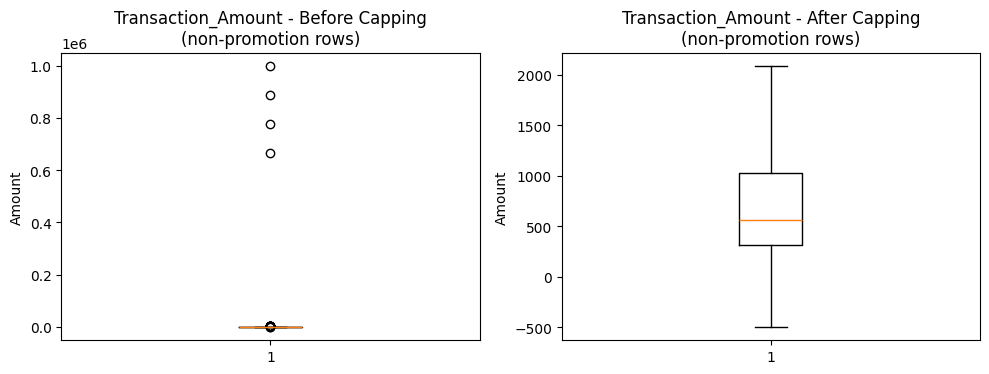

In [7]:
# TODO 6.1: ใช้เฉพาะรายการที่ Is_Promotion != 'Y' คำนวณ Q1, Q3, IQR, Lower Bound, Upper Bound
mask_non_promo = df['Is_Promotion'] != 'Y'
non_promo_amount = df.loc[mask_non_promo, 'Transaction_Amount']

Q1 = non_promo_amount.quantile(0.25)
Q3 = non_promo_amount.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Lower Bound={lower:.2f}, Upper Bound={upper:.2f}")

# TODO 6.2: สร้าง Outlier Flag ก่อนทำ Capping
df['Outlier_Flag_Before_Capping'] = False
df.loc[mask_non_promo, 'Outlier_Flag_Before_Capping'] = ~non_promo_amount.between(lower, upper)
print("\nOutliers detected among non-promotion rows:", df.loc[mask_non_promo, 'Outlier_Flag_Before_Capping'].sum())
print("Promotion rows excluded from outlier detection/capping (kept as-is):", (df['Is_Promotion'] == 'Y').sum())
display(df.loc[df['Outlier_Flag_Before_Capping'], ['Transaction_ID', 'Transaction_Amount', 'Is_Promotion']])

# TODO 6.3: ใช้ .clip() กับ Transaction_Amount เฉพาะรายการที่ไม่ใช่โปรโมชัน
df['Transaction_Amount_Before_Capping'] = df['Transaction_Amount']
df.loc[mask_non_promo, 'Transaction_Amount'] = df.loc[mask_non_promo, 'Transaction_Amount'].clip(lower, upper)
capped_count = int(
    (df.loc[mask_non_promo, 'Transaction_Amount'] != df.loc[mask_non_promo, 'Transaction_Amount_Before_Capping']).sum()
)
print("\nRows capped:", capped_count)

# TODO 6.4: วาด Boxplot ก่อนและหลัง Capping
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(df.loc[mask_non_promo, 'Transaction_Amount_Before_Capping'].dropna())
axes[0].set_title('Transaction_Amount - Before Capping\n(non-promotion rows)')
axes[0].set_ylabel('Amount')
axes[1].boxplot(df.loc[mask_non_promo, 'Transaction_Amount'].dropna())
axes[1].set_title('Transaction_Amount - After Capping\n(non-promotion rows)')
axes[1].set_ylabel('Amount')
plt.tight_layout()
plt.show()


### คำถาม 5
**เพราะเหตุใดข้อมูลที่อยู่นอก IQR Bound จึงไม่จำเป็นต้องเป็นข้อมูลผิดเสมอ?**

IQR เป็นวิธีทางสถิติที่ตรวจจับ "ความผิดปกติเชิงตัวเลข" เมื่อเทียบกับการกระจายตัวส่วนใหญ่ของข้อมูล แต่ไม่ได้รู้จัก
บริบททางธุรกิจเบื้องหลังตัวเลขนั้น ค่าที่อยู่นอกขอบเขตอาจเป็นธุรกรรมจริงที่มีเหตุผลรองรับ เช่น ลูกค้าองค์กรที่ซื้อ
จำนวนมาก (bulk order) หรือสินค้าราคาสูงที่ขายไม่บ่อย ซึ่งเป็นข้อมูลถูกต้องและมีคุณค่าทางธุรกิจ ไม่ใช่ข้อผิดพลาด

**ตัวอย่างจาก Dataset นี้:** รายการที่ `Is_Promotion == 'Y'` ถูกจงใจแยกออกจากการคำนวณ Bound และการทำ Capping
ทั้งหมด เพราะยอดขายที่สูงหรือต่ำผิดปกติในช่วงโปรโมชัน (เช่น flash sale ลดราคาหนัก หรือซื้อ 1 แถม 1 ทำให้ยอดสุทธิ
ต่ำมาก) เป็นผลลัพธ์ตามที่ธุรกิจตั้งใจออกแบบแคมเปญไว้ หากนำรายการเหล่านี้ไปคำนวณ IQR รวมกับรายการปกติ หรือ Capping
ทับยอดของมัน จะทำให้สูญเสียข้อมูลสำคัญเกี่ยวกับประสิทธิภาพของแคมเปญโปรโมชันไปโดยไม่จำเป็น


## 7) Timeliness: ความทันเวลาในการโหลดข้อมูล

In [8]:
# TODO 7: คำนวณ Load_Delay_Hours จาก Order_Date ถึง Load_Timestamp
# กำหนด Late เมื่อมากกว่า 24 ชั่วโมง และสรุปจำนวน/ร้อยละ
df['Load_Delay_Hours'] = (
    (df['Load_Timestamp'] - pd.to_datetime(df['Order_Date'])).dt.total_seconds() / 3600
)
df['Late_Load'] = df['Load_Delay_Hours'] > 24

print("Load_Delay_Hours summary:")
print(df['Load_Delay_Hours'].describe())

late_count = int(df['Late_Load'].sum())
late_pct = df['Late_Load'].mean() * 100
print(f"\nLate loads (> 24 hours): {late_count} rows ({late_pct:.1f}%)")

negative_delay = int((df['Load_Delay_Hours'] < 0).sum())
print(f"Rows where Load_Timestamp is BEFORE Order_Date (data issue to flag): {negative_delay}")


Load_Delay_Hours summary:
count    612.000000
mean      14.346405
std       19.307341
min        1.000000
25%        5.000000
50%       10.000000
75%       16.000000
max      118.000000
Name: Load_Delay_Hours, dtype: float64

Late loads (> 24 hours): 38 rows (6.2%)
Rows where Load_Timestamp is BEFORE Order_Date (data issue to flag): 0


## 8) Data Quality Report และ Export

In [9]:
# TODO 8.1: สรุปตัวชี้วัดก่อนและหลัง Cleaning เป็น DataFrame
raw_invalid_status = int((~df_raw['Order_Status'].isin(['Completed', 'Processing', 'Cancelled', 'Returned'])).sum())
raw_invalid_qty = int((~df_raw['Quantity'].between(1, 20)).sum())

report = pd.DataFrame([
    {'Metric': 'Total rows',                                    'Before': len(df_raw),                          'After': len(df)},
    {'Metric': 'Missing Customer_Email',                        'Before': int(df_raw['Customer_Email'].isnull().sum()), 'After': int(df['Customer_Email'].isnull().sum())},
    {'Metric': 'Missing Province',                               'Before': int(df_raw['Province'].isnull().sum()),        'After': int(df['Province'].isnull().sum())},
    {'Metric': 'Exact duplicate rows',                           'Before': int(df_raw.duplicated().sum()),                'After': int(df.duplicated().sum())},
    {'Metric': 'Duplicate Transaction_ID (business key)',        'Before': int(df_raw['Transaction_ID'].duplicated().sum()), 'After': int(df['Transaction_ID'].duplicated().sum())},
    {'Metric': 'Order_Date requiring fallback/imputation',       'Before': 'n/a (unparsed)',                     'After': int(df['Order_Date_Was_Imputed'].sum())},
    {'Metric': 'Invalid Quantity (outside 1-20)',                'Before': raw_invalid_qty,                      'After': int(df['Quantity_Was_Invalid'].sum())},
    {'Metric': 'Transaction_Amount mismatched vs formula (Accuracy_Flag)', 'Before': 'n/a (not yet computed)',   'After': int(df['Accuracy_Flag'].sum())},
    {'Metric': 'Invalid Order_Status (raw, non-standard)',       'Before': raw_invalid_status,                   'After': int(df['Order_Status_Was_Invalid'].sum())},
    {'Metric': 'Outliers among non-promotion Transaction_Amount', 'Before': int(df['Outlier_Flag_Before_Capping'].sum()), 'After': 0},
    {'Metric': 'Late loads (> 24 hours)',                        'Before': int(df['Late_Load'].sum()),           'After': int(df['Late_Load'].sum())},
])
display(report)

# TODO 8.2: Export
df.to_csv(OUTPUT_DIR / 'e_commerce_clean.csv', index=False, encoding='utf-8-sig')
report.to_csv(OUTPUT_DIR / 'data_quality_report.csv', index=False, encoding='utf-8-sig')
print(f"\nExported clean data and report to: {OUTPUT_DIR}")
print("Files:", [p.name for p in OUTPUT_DIR.iterdir()])


,Metric,Before,After
0,Total rows,630,612
1,Missing Customer_Email,50,0
2,Missing Province,12,0
3,Exact duplicate rows,18,0
4,Duplicate Transaction_ID (business key),18,0
5,Order_Date requiring fallback/imputation,n/a (unparsed),7
6,Invalid Quantity (outside 1-20),3,3
7,Transaction_Amount mismatched vs formula (Accu...,n/a (not yet computed),50
8,"Invalid Order_Status (raw, non-standard)",16,5
9,Outliers among non-promotion Transaction_Amount,19,0



Exported clean data and report to: /home/claude/lab/outputs/student_submission
Files: ['data_quality_report.csv', 'e_commerce_clean.csv']


## 9) Reflection
ตอบเป็นย่อหน้าสั้น ๆ

**1. ขั้นตอนใดมีความเสี่ยงทำให้ข้อมูลจริงสูญหายมากที่สุด?**

ขั้นตอนการจัดการ Missing Values (Task 2) และการลบ Duplicate (Task 4) มีความเสี่ยงสูงสุด เพราะเป็นขั้นตอนเดียวที่มี
การ "ลบแถว" ออกจากชุดข้อมูลจริง หากตั้งเกณฑ์หรือ key ที่ใช้ระบุ duplicate ผิดพลาด (เช่น ใช้ subset ของคอลัมน์ที่แคบ
เกินไป) อาจลบธุรกรรมจริงที่บังเอิญมีค่าคล้ายกันทิ้งไปโดยไม่ตั้งใจ ในขณะที่ขั้นตอนอื่น ๆ (Consistency, Accuracy,
Outlier capping) เป็นการแก้ไขค่าในแถวเดิม ไม่ได้ลบแถวออกจากระบบ

**2. กฎใดควรนำไปทำ Automation ใน Data Pipeline?**

กฎที่มีตรรกะชัดเจนไม่ต้องอาศัยดุลยพินิจของมนุษย์ เหมาะสำหรับ Automation ได้แก่ การมาตรฐานรูปแบบ (Gender,
Payment_Method, Order_Status), การตรวจสอบช่วงค่า Quantity (1-20), การคำนวณ `Expected_Amount` และ
`Accuracy_Flag`, และการคำนวณ `Load_Delay_Hours`/`Late_Load` ส่วนกฎที่ควรมี "จุดพัก" ให้มนุษย์ตรวจสอบก่อน
(human-in-the-loop) คือรายการที่ `Accuracy_Flag = True` และเป็นโปรโมชัน เพราะเกี่ยวข้องกับการตัดสินใจเชิงธุรกิจ

**3. หากใช้ Great Expectations คุณจะสร้าง Expectation ใดอย่างน้อย 3 ข้อ?**

- `expect_column_values_to_not_be_null` บนคอลัมน์ `Transaction_ID`, `Customer_ID`, `Transaction_Amount`
  (คอลัมน์ที่ต้องครบเสมอสำหรับ Fact table)
- `expect_column_values_to_be_between` บนคอลัมน์ `Quantity` (ค่า 1-20) และ `Discount_Rate` (ค่า 0-1)
- `expect_column_values_to_be_in_set` บนคอลัมน์ `Order_Status` (ต้องเป็นหนึ่งใน Completed, Processing,
  Cancelled, Returned, Unknown) และ `Gender` (M, F, Unknown)
- `expect_column_values_to_match_strftime_format` บนคอลัมน์ `Order_Date` เพื่อยืนยันว่าอยู่ในรูปแบบ
  `%Y-%m-%d` หลังผ่านการทำความสะอาดแล้ว
- `expect_compound_columns_to_be_unique` บน `Transaction_ID` เพื่อยืนยัน Uniqueness ของ business key


## Checklist ก่อนส่ง
- [ ] Notebook รันจากบนลงล่างได้โดยไม่ Error
- [ ] มีคำตอบคำถามทั้ง 5 ข้อและ Reflection
- [ ] ส่ง `e_commerce_clean.csv`
- [ ] ส่ง `data_quality_report.csv`
- [ ] ไม่ลบรายการโปรโมชันเพียงเพราะเป็น Outlier
